# LIBRARY

In [1]:
%pip install scikit-plot -q
%pip install scipy -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [3]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error, 
    r2_score
)

# IMPORT CONTROL DATA SET 

In [4]:
file_path = "../1.DATASET/CMI_NN_V2.csv"
df=pd.read_csv(file_path)
df

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.000,50.8,932.498000,NaN,5.0,...,1.0,19.541300,32.690900,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.500000
1,1,9,0,NaN,14.035590,48.000,46.0,936.656000,70.0,NaN,...,1.0,15.410700,27.055200,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
2,2,10,1,71.0,16.648696,56.500,75.6,1115.380000,94.0,5.0,...,1.0,25.512900,42.380000,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.000000
3,3,9,0,71.0,18.292347,56.000,81.6,1131.430000,97.0,6.0,...,2.0,26.479800,45.996600,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
4,4,18,1,65.0,18.140416,54.626,77.0,1578.400000,NaN,NaN,...,2.0,31.506100,42.380000,NaN,1.0,0.0,90.152104,12.000000,26.463732,8.003205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,7,1,NaN,16.229868,46.070,49.0,979.009933,82.5,2.5,...,1.0,19.336600,31.583004,55.0,0.0,0.0,81.861037,6.500000,18.075000,7.000000
8456,8456,10,1,69.5,10.665793,56.130,47.8,1029.411546,80.5,5.0,...,1.0,22.983200,36.475662,NaN,0.0,1.0,79.833333,8.500000,13.575000,5.000000
8457,8457,10,1,70.0,13.509359,49.560,47.2,1034.387599,83.5,7.0,...,2.0,31.594712,35.106855,NaN,2.0,0.0,82.166667,21.500000,16.840263,9.500000
8458,8458,15,1,55.5,17.189894,63.790,99.5,1379.703447,87.5,NaN,...,2.0,46.467581,57.530686,NaN,1.0,2.0,88.395702,10.000000,26.417470,10.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 30 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Age                         8460 non-null   int64  
 2   Basic_Demos-Sex                         8460 non-null   int64  
 3   CGAS-CGAS_Score                         7034 non-null   float64
 4   Physical-BMI                            8460 non-null   float64
 5   Physical-Height                         8460 non-null   float64
 6   Physical-Weight                         8460 non-null   float64
 7   BIA-BIA_BMR                             8460 non-null   float64
 8   Physical-HeartRate                      7539 non-null   float64
 9   Fitness_Endurance-Max_Stage             5480 non-null   float64
 10  FGC-FGC_TL                              6945 non-null   floa

# Data Cleaning

## Removing useless variables

In [6]:
column2drop = ['id']
dfid=df.copy()
df.drop(column2drop, axis=1, inplace=True)

In [7]:
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,5,0,51.0,16.877316,46.000,50.8,932.498,NaN,5.0,6.0,...,1.0,19.5413,32.6909,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.500000
1,9,0,NaN,14.035590,48.000,46.0,936.656,70.0,NaN,3.0,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
2,10,1,71.0,16.648696,56.500,75.6,1115.380,94.0,5.0,5.0,...,1.0,25.5129,42.3800,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.000000
3,9,0,71.0,18.292347,56.000,81.6,1131.430,97.0,6.0,7.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
4,18,1,65.0,18.140416,54.626,77.0,1578.400,NaN,NaN,10.0,...,2.0,31.5061,42.3800,NaN,1.0,0.0,90.152104,12.000000,26.463732,8.003205


In [8]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

# TARGET VARIABLES

## ** TARGET VARIABLE Physical-HeartRate

In [47]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [48]:
df_HeartRate = df[[
        'Basic_Demos-Age',  
        'Physical-Height', 
        'Physical-Weight', 
        'Physical-HeartRate',
        'Physical-MAP_CAL',
       ]].copy()



In [49]:
df_HeartRate=df_HeartRate.dropna()

In [50]:
df_HeartRate.isnull().sum()

Basic_Demos-Age       0
Physical-Height       0
Physical-Weight       0
Physical-HeartRate    0
Physical-MAP_CAL      0
dtype: int64

### Partitioning

In [51]:
attributes = [col for col in df_HeartRate.columns if col != 'Physical-HeartRate']
X = df_HeartRate[attributes].values
y = np.array(df_HeartRate['Physical-HeartRate'])

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [53]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5654, 4) (1885, 4) (5654,) (1885,)


In [54]:
df_HeartRate.shape

(7539, 5)

### Randomized Search

In [55]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [56]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_HeartRate = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_HeartRate = random_search.best_estimator_

In [57]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# rf_reg_HeartRate = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_HeartRate = random_search.best_estimator_

In [58]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.1, 'min_samples_leaf': 100, 'max_depth': 31, 'criterion': 'absolute_error'} -120.5057830215253


In [59]:
dt_reg_HeartRate = random_search.best_estimator_
dt_reg_HeartRate.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=31,
                      min_samples_leaf=100, min_samples_split=0.1)

In [60]:
y_pred = dt_reg_HeartRate.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 10.8987
MAE  : 7.9858
MSE  : 118.7819
R²   : 0.0674


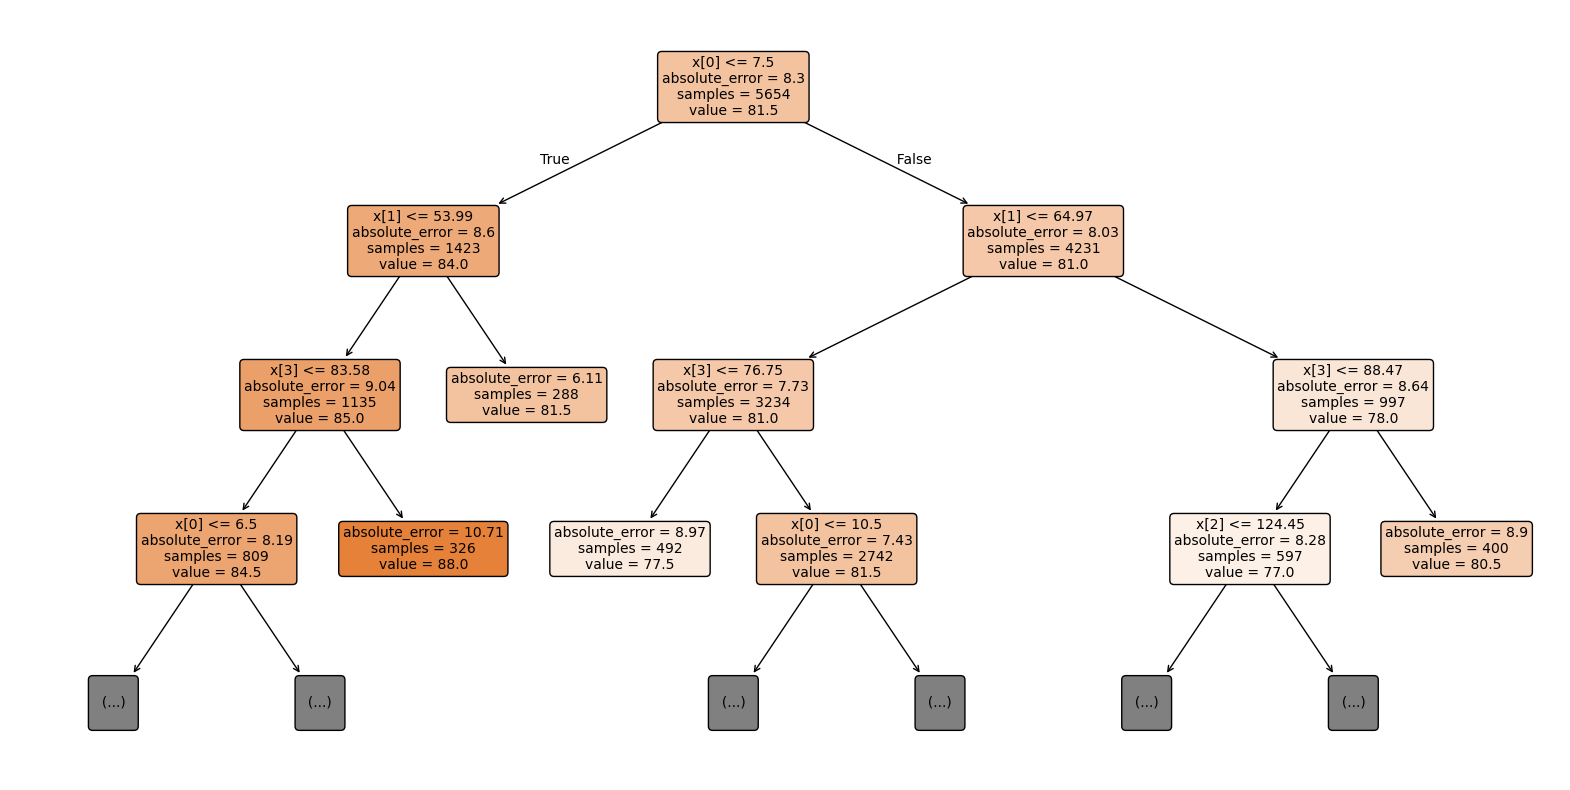

In [61]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_HeartRate,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
1094 | 33.0000 |   81.0000 | 48.0000
1653 | 122.0000 |   80.5000 | 41.5000
1638 | 122.5000 |   81.0000 | 41.5000
1355 | 36.0000 |   77.2500 | 41.2500
 373 | 119.5000 |   81.0000 | 38.5000
1410 | 116.0000 |   77.5000 | 38.5000
 237 | 120.0000 |   82.5000 | 37.5000
1883 | 118.0000 |   81.0000 | 37.0000
 646 | 51.0000 |   88.0000 | 37.0000
 760 | 116.0000 |   80.0000 | 36.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_14172\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


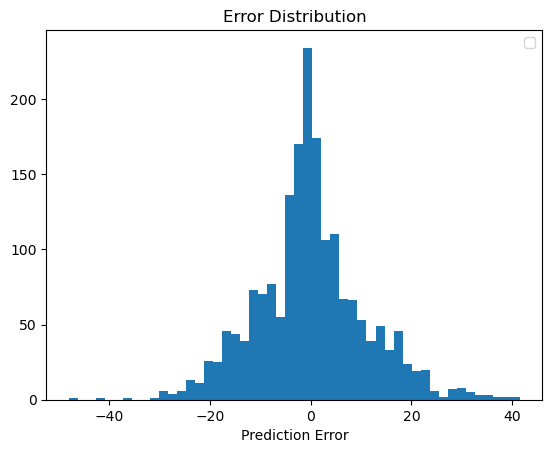

In [62]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [63]:
zipped = zip(attributes, dt_reg_HeartRate.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.4047314578005115
Physical-MAP_CAL 0.27195225916453536
Physical-Height 0.27067348678601877
Physical-Weight 0.05264279624893436


## ** TARGET VARIABLE CGAS-CGAS_Score'

In [185]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [186]:
df_CGAS_Score = df[[
'Basic_Demos-Age', 'Basic_Demos-Sex',
'CGAS-CGAS_Score', 
'Physical-BMI',
'FGC-FGC_CORE_CAL',
'Physical-Weight' , 'Physical-Height'     
       ]].copy()



In [187]:
df_CGAS_Score=df_CGAS_Score[(df_CGAS_Score['CGAS-CGAS_Score']<=100)&(round(df_CGAS_Score['CGAS-CGAS_Score'],0)!=65)]

In [188]:
df_CGAS_Score

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,FGC-FGC_CORE_CAL,Physical-Weight,Physical-Height
0,5,0,51.0,16.877316,4.611111,50.8,46.00
2,10,1,71.0,16.648696,27.000000,75.6,56.50
3,9,0,71.0,18.292347,23.000000,81.6,56.00
5,13,1,50.0,22.279952,18.000000,112.2,59.50
11,11,0,66.0,17.894545,18.198142,77.0,55.00
...,...,...,...,...,...,...,...
8452,6,1,65.5,11.558486,7.000000,48.8,54.48
8456,10,1,69.5,10.665793,8.500000,47.8,56.13
8457,10,1,70.0,13.509359,21.500000,47.2,49.56
8458,15,1,55.5,17.189894,10.000000,99.5,63.79


In [189]:
df_CGAS_Score.isnull().sum()

Basic_Demos-Age     0
Basic_Demos-Sex     0
CGAS-CGAS_Score     0
Physical-BMI        0
FGC-FGC_CORE_CAL    0
Physical-Weight     0
Physical-Height     0
dtype: int64

In [190]:
df_CGAS_Score=df_CGAS_Score.dropna()

In [191]:
df_CGAS_Score.isnull().sum()

Basic_Demos-Age     0
Basic_Demos-Sex     0
CGAS-CGAS_Score     0
Physical-BMI        0
FGC-FGC_CORE_CAL    0
Physical-Weight     0
Physical-Height     0
dtype: int64

### Partitioning

In [192]:
attributes = [col for col in df_CGAS_Score.columns if col != 'CGAS-CGAS_Score']
X = df_CGAS_Score[attributes].values
y = np.array(df_CGAS_Score['CGAS-CGAS_Score'])

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [194]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4445, 6) (1482, 6) (4445,) (1482,)


In [195]:
df_CGAS_Score.shape

(5927, 7)

### Randomized Search

In [196]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [197]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_CGAS_Score = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_CGAS_Score = random_search.best_estimator_

In [198]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_CGAS_Score = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_CGAS_Score = random_search.best_estimator_

In [199]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 50, 'max_depth': 3, 'criterion': 'squared_error'} -105.72838225473859


In [200]:
dt_reg_CGAS_Score = random_search.best_estimator_
dt_reg_CGAS_Score.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=50, min_samples_split=0.002)

In [201]:
y_pred = dt_reg_CGAS_Score.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 10.0721
MAE  : 7.9844
MSE  : 101.4469
R²   : 0.0327


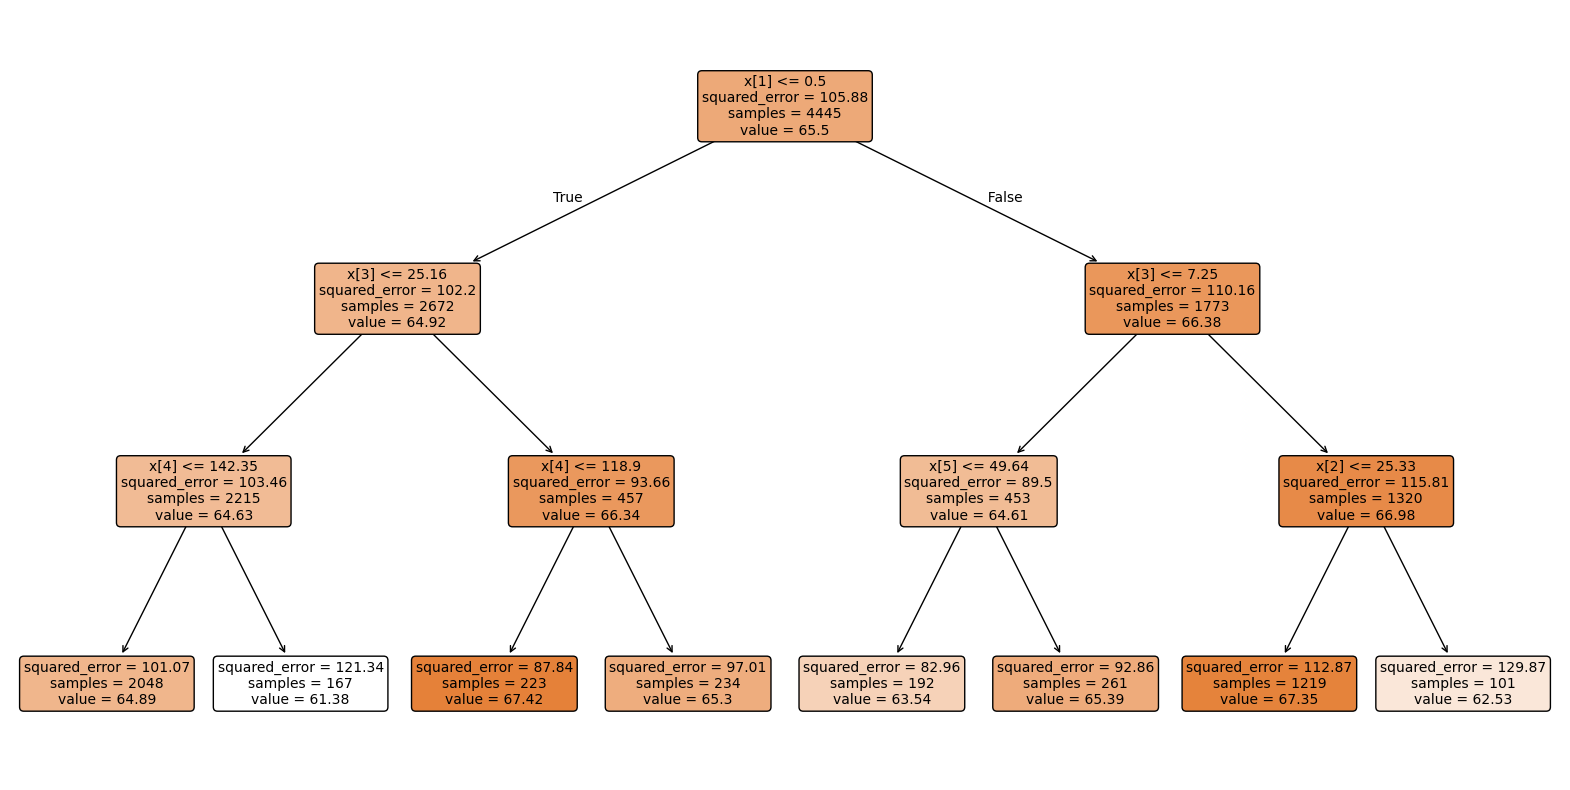

In [202]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_CGAS_Score,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  22 | 30.0000 |   62.5347 | 32.5347
 547 | 33.0000 |   65.3034 | 32.3034
1408 | 35.0000 |   64.8931 | 29.8931
 677 | 35.0000 |   64.8931 | 29.8931
 249 | 95.0000 |   67.4238 | 27.5762
 515 | 95.0000 |   67.4238 | 27.5762
 924 | 35.0000 |   62.5347 | 27.5347
1111 | 40.0000 |   67.3495 | 27.3495
 570 | 38.0000 |   64.8931 | 26.8931
 422 | 90.0000 |   63.5417 | 26.4583


C:\Users\paula\AppData\Local\Temp\ipykernel_14172\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


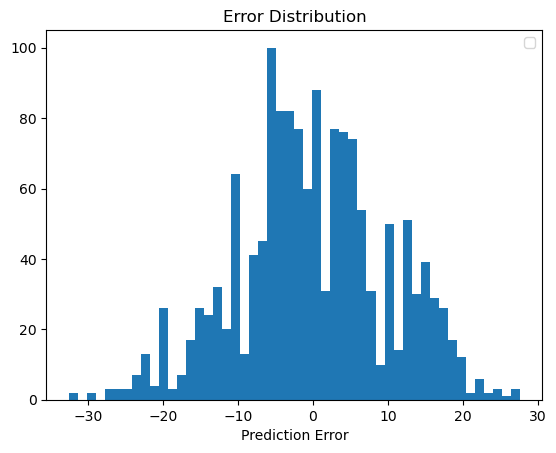

In [203]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [204]:
zipped = zip(attributes, dt_reg_CGAS_Score.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

FGC-FGC_CORE_CAL 0.29400680933607476
Physical-Weight 0.2366660314907708
Basic_Demos-Sex 0.2205931511019192
Physical-BMI 0.21156989140127805
Physical-Height 0.037164116669957115
Basic_Demos-Age 0.0


## ** TARGET VARIABLE Fitness_Endurance-Max_Stage

In [308]:
df_Fitness_Endurance= df[[
'Physical-Weight',
'FGC-FGC_CORE_CAL',
'Basic_Demos-Age', 
'Physical-Height',
'Physical-MAP_CAL',
'Fitness_Endurance-Max_Stage'
]]



In [309]:
df_Fitness_Endurance=df_Fitness_Endurance.dropna()

In [310]:
df_Fitness_Endurance["Fitness_Endurance-Max_Stage"] = df_Fitness_Endurance["Fitness_Endurance-Max_Stage"].astype(int)

In [311]:
df_Fitness_Endurance=df_Fitness_Endurance[(df_Fitness_Endurance["Fitness_Endurance-Max_Stage"] >=3) & (df_Fitness_Endurance["Fitness_Endurance-Max_Stage"]<=8)]

In [312]:
df_Fitness_Endurance.isnull().sum()

Physical-Weight                0
FGC-FGC_CORE_CAL               0
Basic_Demos-Age                0
Physical-Height                0
Physical-MAP_CAL               0
Fitness_Endurance-Max_Stage    0
dtype: int64

### Partitioning

In [313]:
attributes = [col for col in df_Fitness_Endurance.columns if col != 'Fitness_Endurance-Max_Stage']
X = df_Fitness_Endurance[attributes].values
y = np.array(df_Fitness_Endurance['Fitness_Endurance-Max_Stage'])

In [314]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)


In [315]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3969, 5) (1324, 5) (3969,) (1324,)


In [316]:
df_Fitness_Endurance.shape

(5293, 6)

### Randomized Search

In [317]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_Fitness_Endurance = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_Fitness_Endurance = random_search.best_estimator_

In [318]:
# param_list = {
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_Fitness_Endurance = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_Fitness_Endurance = random_search.best_estimator_

In [319]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 20)),
#     'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['gini', 'entropy']
# }

# dt_reg_Fitness_Endurance = RandomForestClassifier(random_state=0)

# random_search = RandomizedSearchCV(
#     estimator=RandomForestClassifier(random_state=0), # Added random_state for reproducibility
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0),
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Good practice for RandomizedSearchCV
# )

# random_search.fit(X_train, y_train)
# dt_reg_Fitness_Endurance = random_search.best_estimator_

In [320]:
# param_list = {
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
# }

# dt_reg_Fitness_Endurance  = DecisionTreeRegressor()  

# random_search = RandomizedSearchCV(
#     DecisionTreeRegressor(),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error' ,   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
# )

# random_search.fit(X_train, y_train)
# dt_reg_Fitness_Endurance  = random_search.best_estimator_

In [321]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.2, 'min_samples_leaf': 20, 'max_depth': 18, 'criterion': 'entropy'} 0.6308804050555712


In [322]:
dt_reg_Fitness_Endurance = random_search.best_estimator_
dt_reg_Fitness_Endurance.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=18, min_samples_leaf=20,
                       min_samples_split=0.2)

In [323]:
y_pred = dt_reg_Fitness_Endurance.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6306646525679759
              precision    recall  f1-score   support

           3       0.00      0.00      0.00        41
           4       0.00      0.00      0.00       295
           5       0.63      1.00      0.77       835
           6       0.00      0.00      0.00       118
           7       0.00      0.00      0.00        29
           8       0.00      0.00      0.00         6

    accuracy                           0.63      1324
   macro avg       0.11      0.17      0.13      1324
weighted avg       0.40      0.63      0.49      1324



c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [324]:
# y_pred = dt_reg_Fitness_Endurance.predict(X_test)

# print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
# print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
# print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
# print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

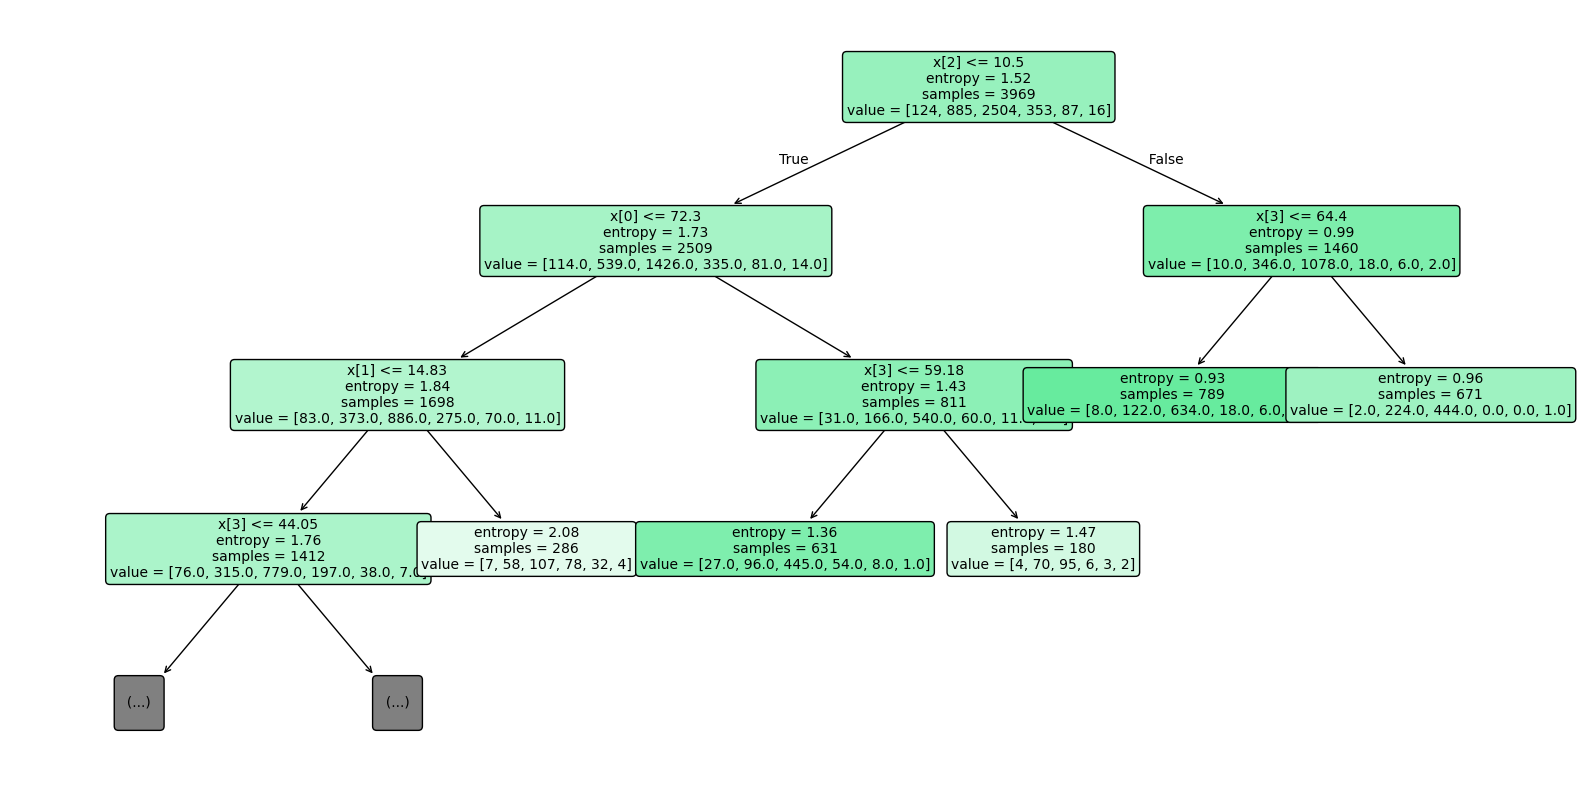

In [325]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_Fitness_Endurance,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  96 |  8.0000 |    5.0000 | 3.0000
 762 |  8.0000 |    5.0000 | 3.0000
  92 |  8.0000 |    5.0000 | 3.0000
1201 |  8.0000 |    5.0000 | 3.0000
 325 |  8.0000 |    5.0000 | 3.0000
  73 |  8.0000 |    5.0000 | 3.0000
 636 |  3.0000 |    5.0000 | 2.0000
 670 |  3.0000 |    5.0000 | 2.0000
 141 |  3.0000 |    5.0000 | 2.0000
1208 |  3.0000 |    5.0000 | 2.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_14172\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


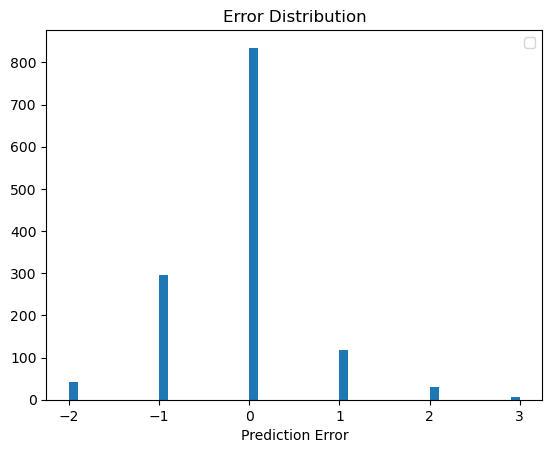

In [326]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [327]:
zipped = zip(attributes, dt_reg_Fitness_Endurance.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.5208108913123831
Physical-Height 0.2745814540124493
FGC-FGC_CORE_CAL 0.10550174543421427
Physical-Weight 0.09910590924095328
Physical-MAP_CAL 0.0


## ** TARGET VARIABLE FGC-FGC_TL

In [328]:
df_FGC_TL= df[[
'FGC-FGC_TL',
'FGC-FGC_CORE_CAL',
'FGC-FGC_SR_CAL',
'BIA-BIA_ECW',
'Basic_Demos-Age',
'Basic_Demos-Sex',
'Physical-Weight',
'Physical-Height',
'BIA-BIA_TBW'
]]





In [329]:
df_FGC_TL=df_FGC_TL.dropna()

In [330]:
df_FGC_TL.isnull().sum()

FGC-FGC_TL          0
FGC-FGC_CORE_CAL    0
FGC-FGC_SR_CAL      0
BIA-BIA_ECW         0
Basic_Demos-Age     0
Basic_Demos-Sex     0
Physical-Weight     0
Physical-Height     0
BIA-BIA_TBW         0
dtype: int64

### Partitioning

In [331]:
attributes = [col for col in df_FGC_TL.columns if col != 'FGC-FGC_TL']
X = df_FGC_TL[attributes].values
y = np.array(df_FGC_TL['FGC-FGC_TL'])

In [332]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [333]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5208, 8) (1736, 8) (5208,) (1736,)


In [334]:
df_FGC_TL.shape

(6944, 9)

### Randomized Search

In [335]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [336]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FGC_TL = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=10, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FGC_TL = random_search.best_estimator_

In [337]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_FGC_TL = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_FGC_TL = random_search.best_estimator_

In [338]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.1, 'min_samples_leaf': 30, 'max_depth': 42, 'criterion': 'friedman_mse'} -5.714326214230198


In [339]:
dt_reg_FGC_TL = random_search.best_estimator_
dt_reg_FGC_TL.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=42,
                      min_samples_leaf=30, min_samples_split=0.1)

In [340]:
y_pred = dt_reg_FGC_TL.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 2.4322
MAE  : 1.8049
MSE  : 5.9154
R²   : 0.1372


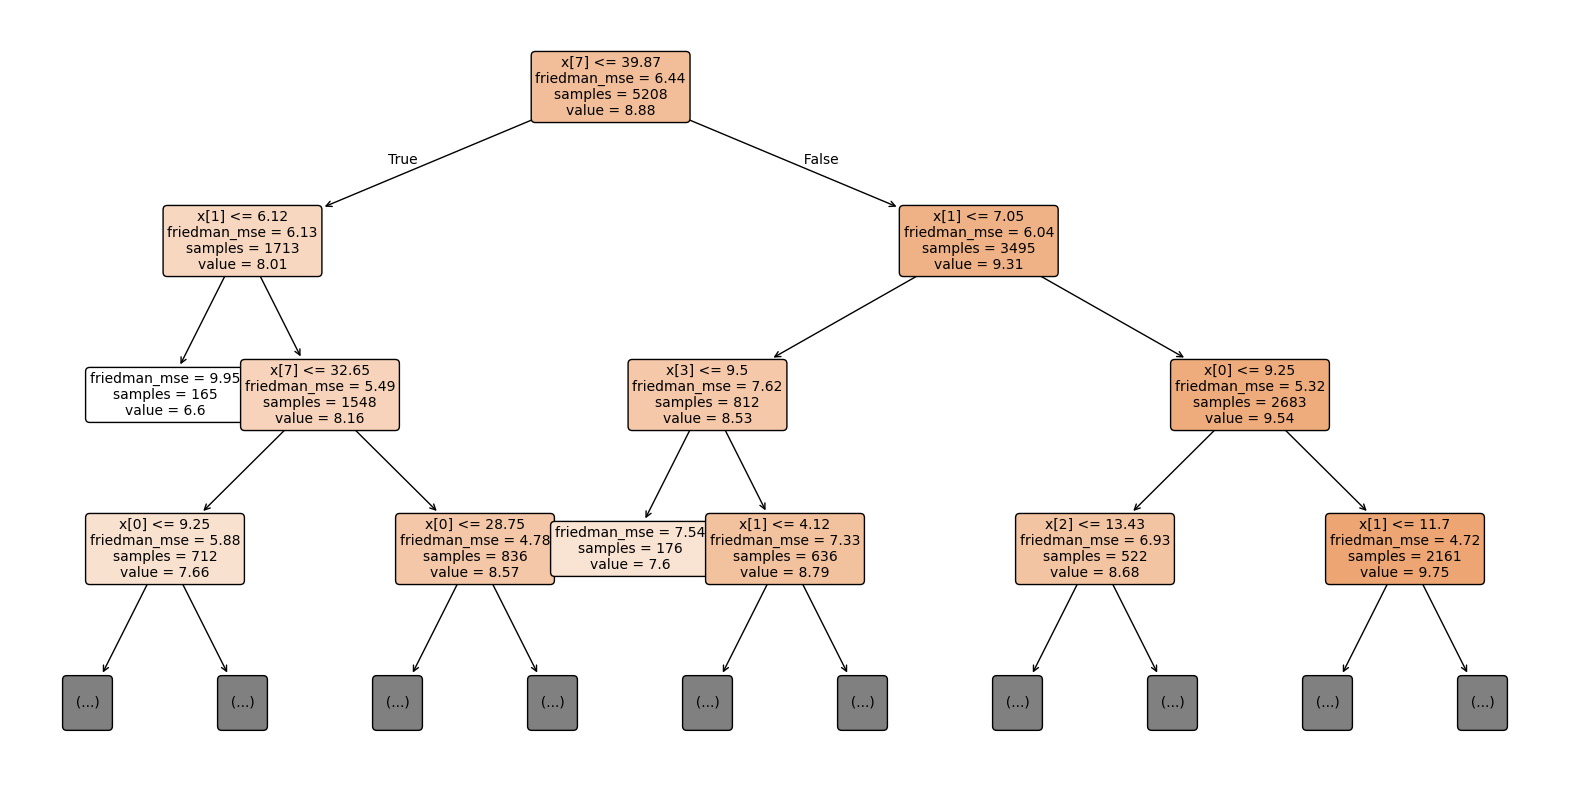

In [341]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FGC_TL,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
1208 | 19.0000 |    7.6023 | 11.3977
1156 | 22.0000 |   11.0303 | 10.9697
 500 | 20.0000 |    9.5634 | 10.4366
 958 |  0.0000 |    9.4579 | 9.4579
1205 |  0.0000 |    9.3793 | 9.3793
1274 |  0.0000 |    8.2543 | 8.2543
 770 |  3.0000 |   11.0303 | 8.0303
1112 |  0.0000 |    7.9203 | 7.9203
1086 |  0.0000 |    7.9203 | 7.9203
 677 |  0.0000 |    7.3219 | 7.3219


C:\Users\paula\AppData\Local\Temp\ipykernel_14172\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


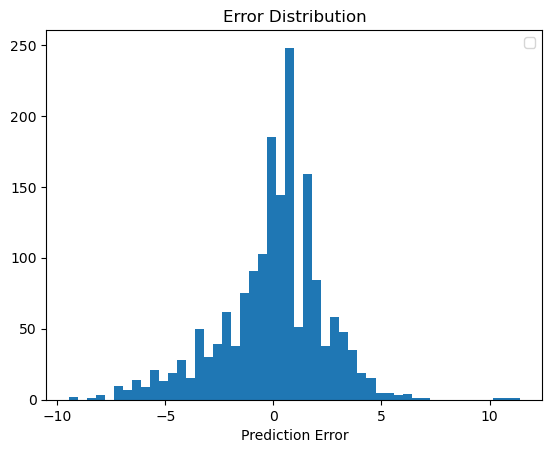

In [342]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [343]:
zipped = zip(attributes, dt_reg_FGC_TL.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_TBW 0.42623863416500135
FGC-FGC_SR_CAL 0.29871197293317014
FGC-FGC_CORE_CAL 0.16485901409391446
Physical-Weight 0.042893452957421196
Basic_Demos-Age 0.03657626369940084
BIA-BIA_ECW 0.030720662151091913
Basic_Demos-Sex 0.0
Physical-Height 0.0


## ** TARGET VARIABLE SDS-SDS_Total_T

In [346]:
df_SDS_Total= df[[
'SDS-SDS_Total_T',
'Basic_Demos-Age','Basic_Demos-Sex', 'Physical-Weight',
'Physical-Height','BIA-BIA_FMI'
]]




In [347]:
df_SDS_Total=df_SDS_Total.dropna()

In [348]:
df_SDS_Total.isnull().sum()

SDS-SDS_Total_T    0
Basic_Demos-Age    0
Basic_Demos-Sex    0
Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
dtype: int64

### Partitioning

In [349]:
attributes = [col for col in df_SDS_Total.columns if col != 'SDS-SDS_Total_T']
X = df_SDS_Total[attributes].values
y = np.array(df_SDS_Total['SDS-SDS_Total_T'])

In [350]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [351]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3677, 5) (1226, 5) (3677,) (1226,)


In [352]:
df_SDS_Total.shape

(4903, 6)

### Randomized Search

In [353]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [354]:
param_list = {
    'max_depth': [None] + list(np.arange(10, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_SDS_Total = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_SDS_Total = random_search.best_estimator_

In [355]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_SDS_Total = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_SDS_Total = random_search.best_estimator_

In [356]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.2, 'min_samples_leaf': 150, 'max_depth': 35, 'criterion': 'friedman_mse'} -159.95863470112667


In [357]:
dt_reg_SDS_Total = random_search.best_estimator_
dt_reg_SDS_Total.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=35,
                      min_samples_leaf=150, min_samples_split=0.2)

In [358]:
y_pred = dt_reg_SDS_Total.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 12.6040
MAE  : 9.3769
MSE  : 158.8614
R²   : -0.0126


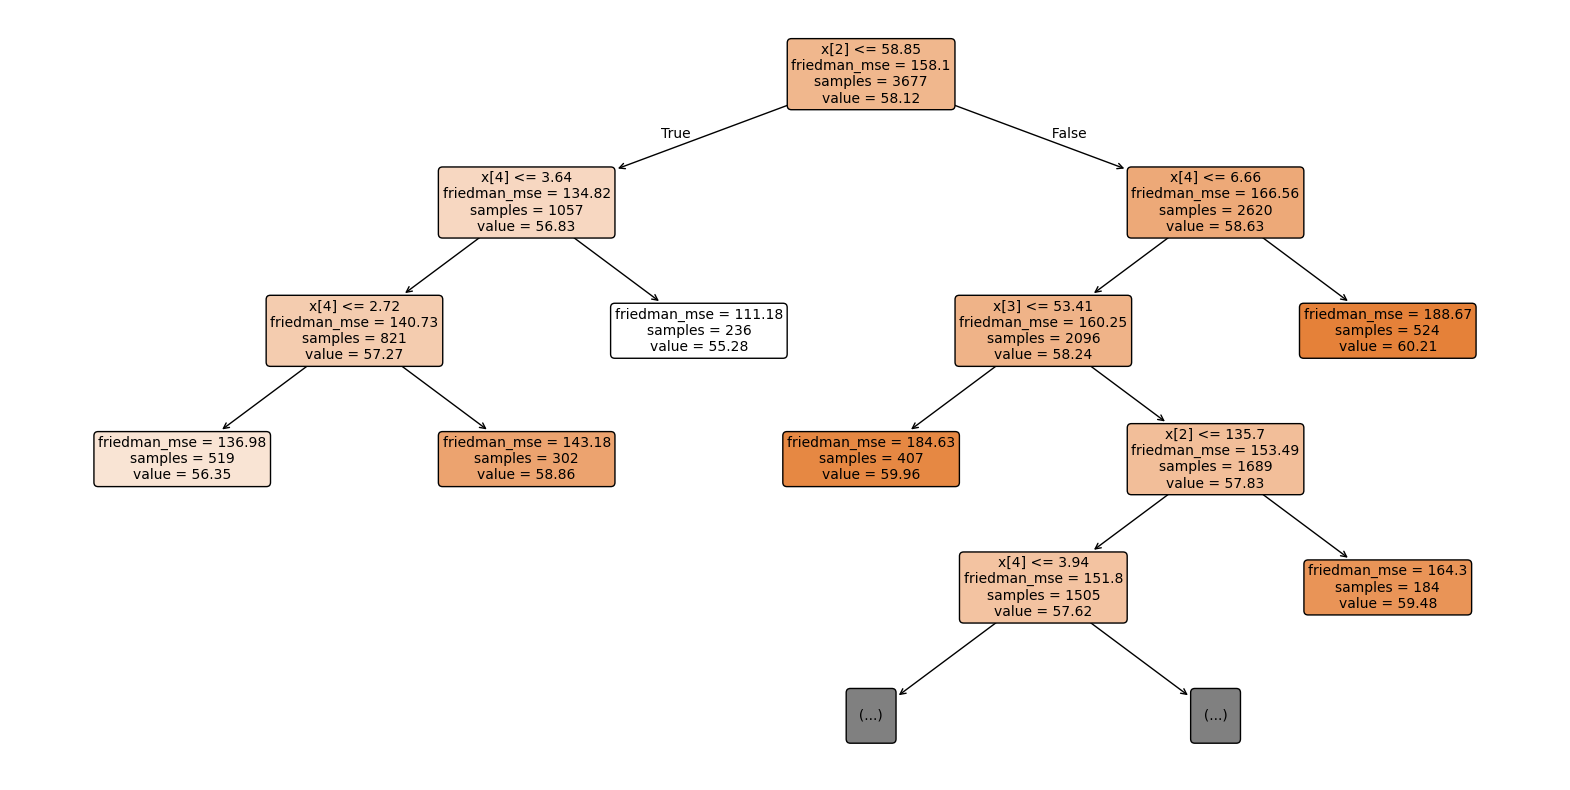

In [359]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_SDS_Total,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 293 | 100.0000 |   55.2797 | 44.7203
 448 | 100.0000 |   56.3497 | 43.6503
 103 | 100.0000 |   56.3497 | 43.6503
 728 | 100.0000 |   56.3497 | 43.6503
 257 | 100.0000 |   56.3497 | 43.6503
 319 | 100.0000 |   56.7635 | 43.2365
 953 | 100.0000 |   56.7635 | 43.2365
1017 | 100.0000 |   56.7635 | 43.2365
 262 | 99.5000 |   56.3497 | 43.1503
 669 | 100.0000 |   57.2474 | 42.7526


C:\Users\paula\AppData\Local\Temp\ipykernel_14172\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


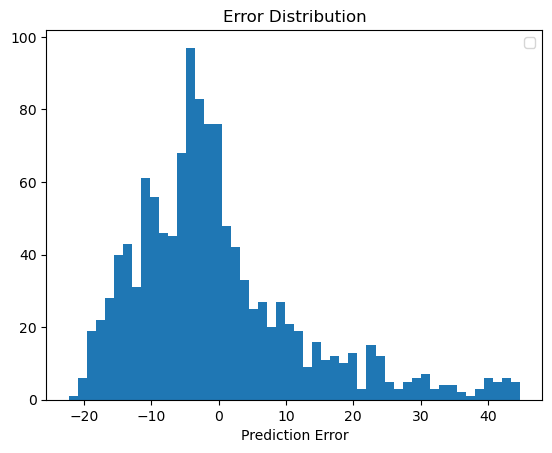

In [360]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [361]:
zipped = zip(attributes, dt_reg_SDS_Total.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_FMI 0.5153312705309249
Physical-Weight 0.32446591418908305
Physical-Height 0.16020281527999203
Basic_Demos-Age 0.0
Basic_Demos-Sex 0.0


## ** TARGET VARIABLE PreInt_EduHx-computerinternet_hoursday'

In [384]:
df_computerinternet= df[[
'Basic_Demos-Age', 'CGAS-CGAS_Score', 
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'FGC-FGC_TL',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW',
       'PreInt_EduHx-computerinternet_hoursday'
]]



In [385]:
df_computerinternet=df_computerinternet.dropna()

In [386]:
df_computerinternet.isnull().sum()

Basic_Demos-Age                           0
CGAS-CGAS_Score                           0
Physical-Height                           0
Physical-Weight                           0
BIA-BIA_BMR                               0
Physical-HeartRate                        0
FGC-FGC_TL                                0
BIA-BIA_Frame_num                         0
BIA-BIA_SMM                               0
BIA-BIA_TBW                               0
PreInt_EduHx-computerinternet_hoursday    0
dtype: int64

### Partitioning

In [387]:
attributes = [col for col in df_computerinternet.columns if col != 'PreInt_EduHx-computerinternet_hoursday']
X = df_computerinternet[attributes].values
y = np.array(df_computerinternet['PreInt_EduHx-computerinternet_hoursday'])

In [388]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [389]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3817, 10) (1273, 10) (3817,) (1273,)


In [390]:
df_computerinternet.shape

(5090, 11)

### Randomized Search

In [391]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [392]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_computerinternet = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_computerinternet = random_search.best_estimator_

In [393]:
# param_list = {
#     'max_depth': [None] + list(np.arange(10, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
# }

# dt_reg_computerinternet = DecisionTreeRegressor()  

# random_search = RandomizedSearchCV(
#     DecisionTreeRegressor(),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error' ,   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
# )

# random_search.fit(X_train, y_train)
# dt_reg_computerinternet = random_search.best_estimator_

In [394]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.01, 'min_samples_leaf': 20, 'max_depth': 3, 'criterion': 'entropy'} 0.5294727343841135


In [395]:
dt_reg_computerinternet = random_search.best_estimator_
dt_reg_computerinternet.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=20,
                       min_samples_split=0.01)

In [396]:
y_pred = dt_reg_computerinternet.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5113904163393559
              precision    recall  f1-score   support

         0.0       0.57      0.80      0.67       602
         1.0       0.00      0.00      0.00       227
         2.0       0.39      0.50      0.44       337
         3.0       0.00      0.00      0.00       107

    accuracy                           0.51      1273
   macro avg       0.24      0.32      0.28      1273
weighted avg       0.37      0.51      0.43      1273



c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [397]:
# y_pred = dt_reg_computerinternet.predict(X_test)

# print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
# print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
# print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
# print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

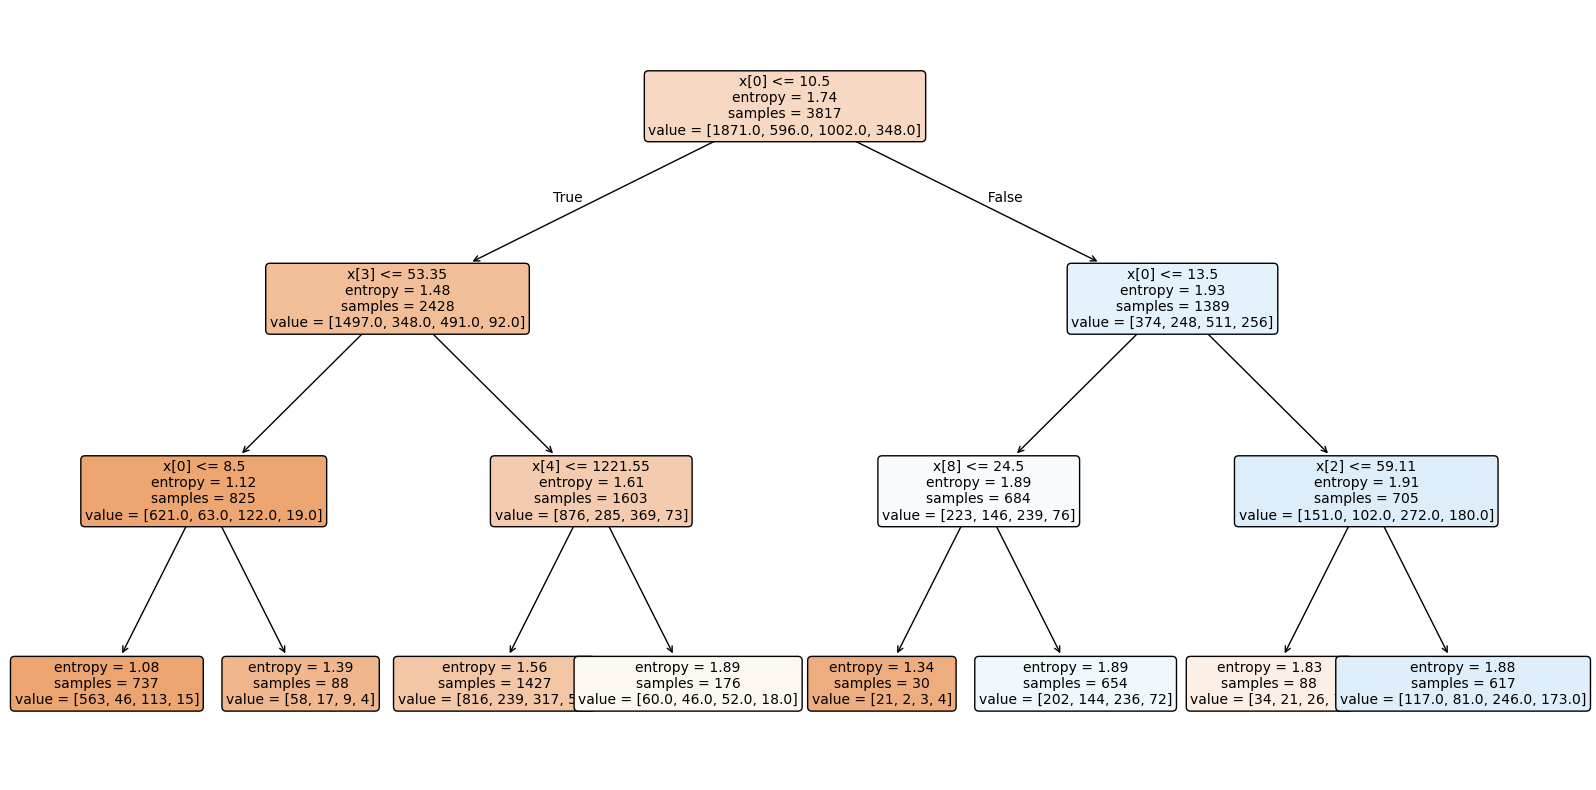

In [398]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_computerinternet,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 379 |  3.0000 |    0.0000 | 3.0000
  52 |  3.0000 |    0.0000 | 3.0000
 844 |  3.0000 |    0.0000 | 3.0000
 132 |  3.0000 |    0.0000 | 3.0000
 744 |  3.0000 |    0.0000 | 3.0000
 453 |  3.0000 |    0.0000 | 3.0000
 536 |  3.0000 |    0.0000 | 3.0000
 308 |  3.0000 |    0.0000 | 3.0000
 637 |  3.0000 |    0.0000 | 3.0000
 480 |  3.0000 |    0.0000 | 3.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_14172\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


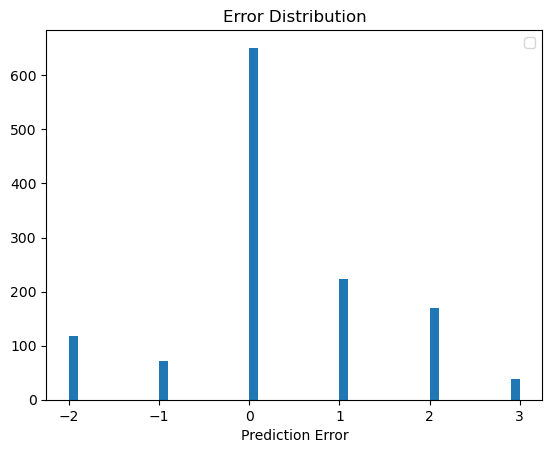

In [399]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [400]:
zipped = zip(attributes, dt_reg_computerinternet.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.7524610215640444
Physical-Weight 0.130468461515804
BIA-BIA_BMR 0.04684935631548643
Physical-Height 0.04296009636892981
BIA-BIA_SMM 0.027261064235735405
CGAS-CGAS_Score 0.0
Physical-HeartRate 0.0
FGC-FGC_TL 0.0
BIA-BIA_Frame_num 0.0
BIA-BIA_TBW 0.0
